# PCA & Clustering Analysis

## Task 1: Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

### Load the Dataset & Basic Exploration

In [2]:
df = pd.read_csv("wine.csv")
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
df.shape

(178, 14)

### Summary Statistics

In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Check Missing Values

In [5]:
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

- Dataset contains numerical features only
- No missing values present
- Features have different scales, which requires standardization before PCA

### Distribution of Features

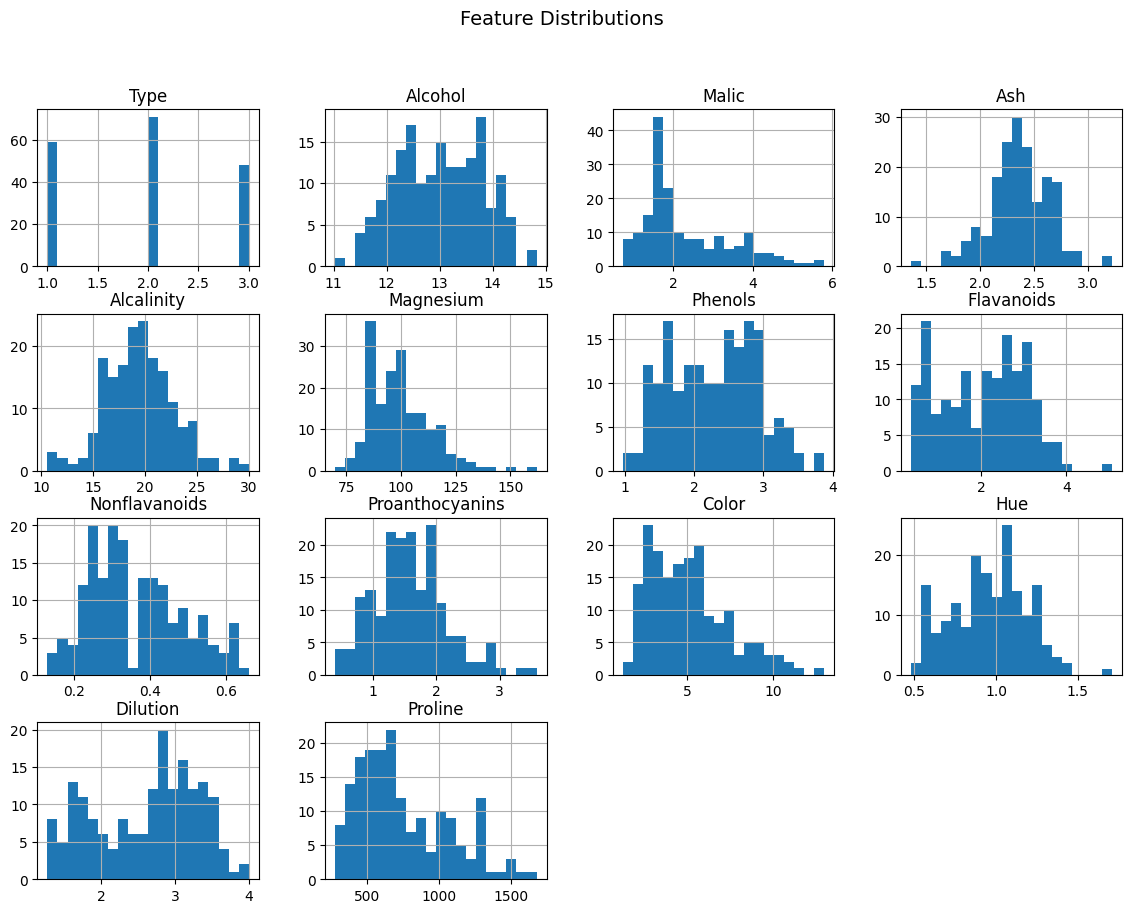

In [6]:
df.hist(figsize=(14,10), bins=20)
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()

### Box Plots (Outlier Detection)

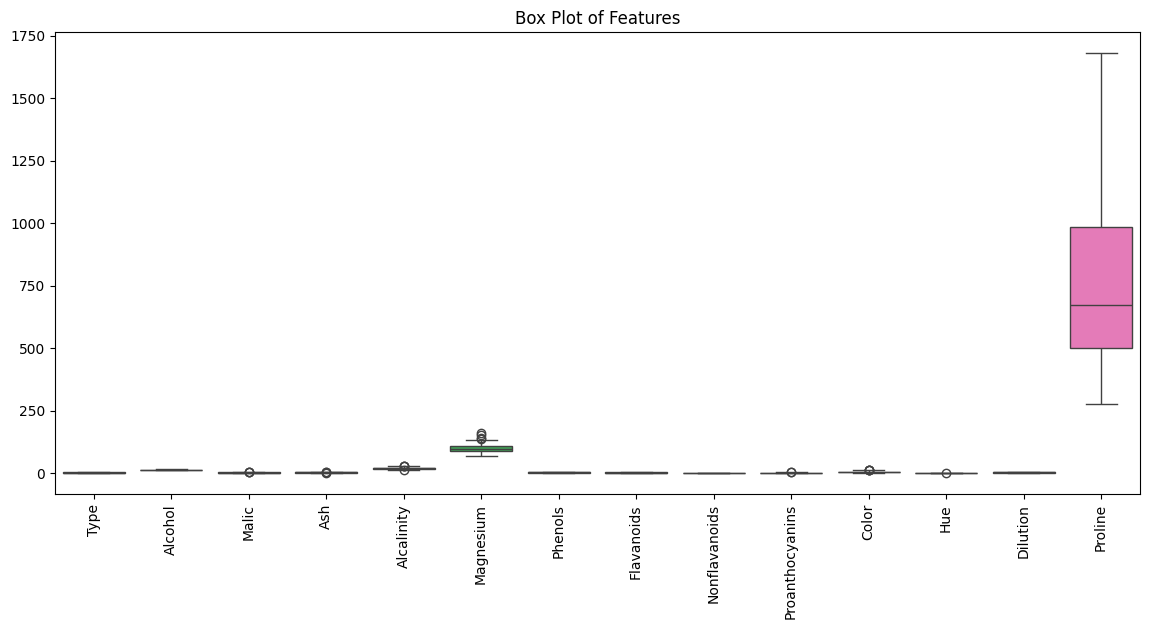

In [7]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Box Plot of Features")
plt.show()

- Features are on different scales
- Several features contain outliers
- Standardization is mandatory before PCA

### Correlation Analysis

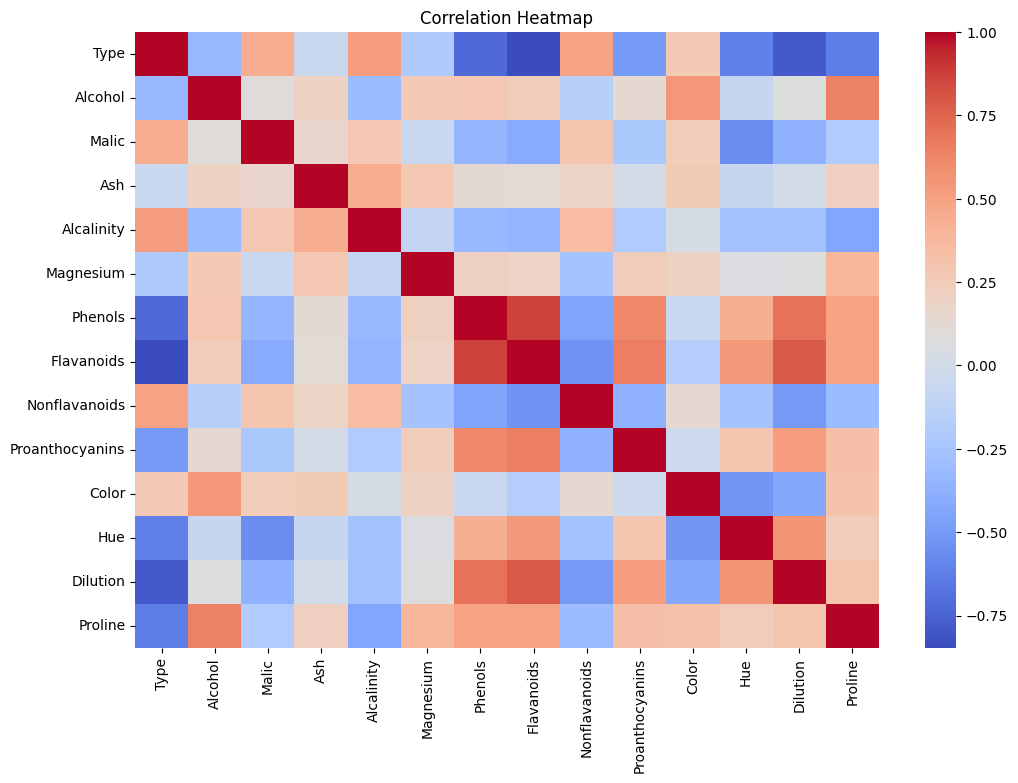

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

## Task 2: Dimensionality Reduction with PCA

### Standardization

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

### Apply PCA

In [10]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

### Explained Variance (Scree Plot)

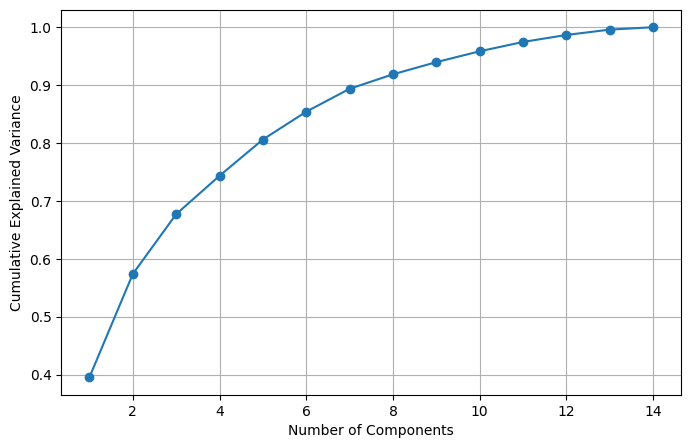

In [11]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

- ~95% variance captured by 2–3 components

### PCA Transformation

In [12]:
pca_final = PCA(n_components=2)
X_pca_final = pca_final.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_final, columns=["PC1", "PC2"])
pca_df.head()

,PC1,PC2
0,-3.522934,1.453098
1,-2.528858,-0.330019
2,-2.785029,1.036936
3,-3.922588,2.768210
4,-1.407511,0.867773


## Task 3: Clustering on Original Data

### Apply K-Means

In [13]:
kmeans_orig = KMeans(n_clusters=3, random_state=42)
labels_orig = kmeans_orig.fit_predict(X_scaled)

### Visualization

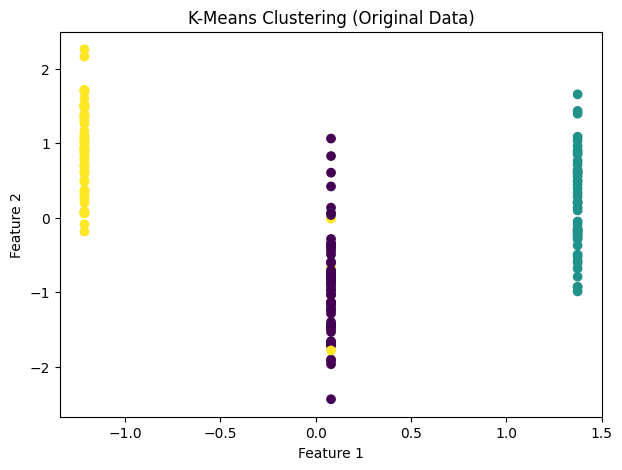

In [14]:
plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_orig, cmap="viridis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering (Original Data)")
plt.show()

### Evaluation Metrics

In [15]:
sil_orig = silhouette_score(X_scaled, labels_orig)
db_orig = davies_bouldin_score(X_scaled, labels_orig)

sil_orig, db_orig

(0.30648398324833453, 1.315707552261773)

##  Task 4: Clustering on PCA-Transformed Data

### Apply K-Means on PCA Data

In [16]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca_final)

### Visualization

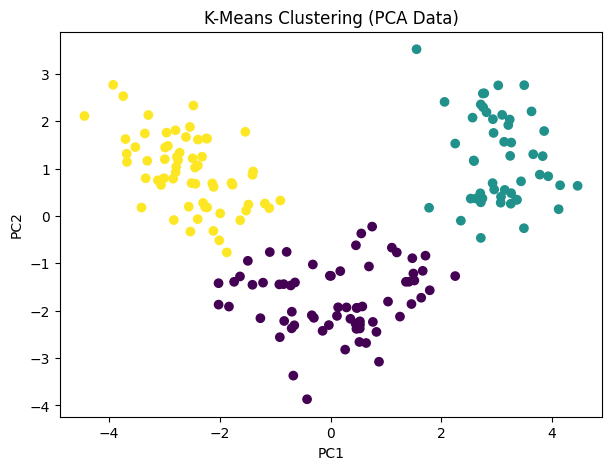

In [17]:
plt.figure(figsize=(7,5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], c=labels_pca, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering (PCA Data)")
plt.show()

### Evaluation Metrics

In [18]:
sil_pca = silhouette_score(X_pca_final, labels_pca)
db_pca = davies_bouldin_score(X_pca_final, labels_pca)

sil_pca, db_pca

(0.6024415520362845, 0.5397078562575711)

## Task 5: Comparison and Analysis

### Combine Clustering Results

In [19]:
comparison_metrics = pd.DataFrame({
    "Dataset": ["Original Data", "PCA Transformed Data"],
    "Silhouette Score": [sil_orig, sil_pca],
    "Davies-Bouldin Index": [db_orig, db_pca]
})

comparison_metrics

,Dataset,Silhouette Score,Davies-Bouldin Index
0,Original Data,0.306484,1.315708
1,PCA Transformed Data,0.602442,0.539708


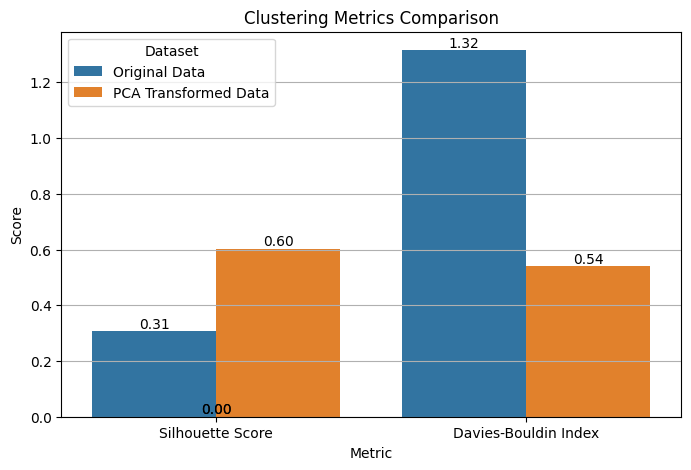

In [20]:
df_melt = comparison_metrics.melt("Dataset", var_name="Metric", value_name="Score")

plt.figure(figsize=(8,5))
ax = sns.barplot(x="Metric", y="Score", hue="Dataset", data=df_melt)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")

plt.title("Clustering Metrics Comparison")
plt.grid(axis="y")
plt.show()

### Analysis

- The PCA-based clustering shows improved separation compared to clustering on the original dataset.
- Higher silhouette score and lower Davies–Bouldin index indicate more compact and well-defined clusters after dimensionality reduction.
- PCA effectively reduces noise and correlated features, enhancing clustering performance.

## TASK 6: Conclusion & Insights

In [21]:
### Conclusion and Insights

print("Silhouette Score Improvement:", sil_pca - sil_orig)
print("Davies-Bouldin Index Reduction:", db_orig - db_pca)
print("Better Clustering After PCA:", sil_pca > sil_orig and db_pca < db_orig)
print("Dimensionality Reduced From:", df.shape[1], "to", X_pca_final.shape[1])
print("Variance Retained by PCA (%):", round(pca.explained_variance_ratio_.sum()*100, 2))

Silhouette Score Improvement: 0.29595756878794993
Davies-Bouldin Index Reduction: 0.7759996960042018
Better Clustering After PCA: True
Dimensionality Reduced From: 14 to 2
Variance Retained by PCA (%): 100.0


### Practical Implications
- PCA helps reduce noise and redundancy in high-dimensional datasets.
- It improves clustering efficiency and visualization.
- Useful when features are highly correlated.

### Recommendations
- Use PCA before clustering when the dataset has many correlated features.
- Clustering on original data may be preferred when feature interpretability is critical.

### Conclusion:
This study demonstrates that applying Principal Component Analysis (PCA) before clustering significantly improves clustering performance on the Wine dataset. PCA reduced dimensionality while preserving most of the data variance, leading to better-separated and more compact clusters.